# Play Store App Review Analysis

## Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load Dataset

In [32]:
playstore = pd.read_csv("Play Store Data.csv")
reviews = pd.read_csv("User Reviews.csv")

## Data Understanding

In [33]:
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [34]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [35]:
playstore.shape

(10841, 13)

In [36]:
reviews.shape

(64295, 5)

In [37]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [38]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [39]:
playstore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [40]:
reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


## Data Cleaning

In [41]:
playstore.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [42]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [43]:
playstore.duplicated().sum()

483

In [44]:
reviews.duplicated().sum()

33616

In [45]:
playstore.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [46]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [47]:
playstore = playstore.drop_duplicates()
reviews = reviews.drop_duplicates()

In [48]:
playstore.duplicated().sum()

0

In [49]:
reviews.duplicated().sum()

0

In [50]:
playstore["Rating"] = playstore["Rating"].fillna(playstore["Rating"].median())

playstore["Type"] = playstore["Type"].fillna(playstore["Type"].mode()[0])

playstore["Content Rating"] = playstore["Content Rating"].fillna(playstore["Content Rating"].mode()[0])

playstore["Current Ver"] = playstore["Current Ver"].fillna(playstore["Current Ver"].mode()[0])

playstore["Android Ver"] = playstore["Android Ver"].fillna(playstore["Android Ver"].mode()[0])

In [51]:
playstore.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [52]:
playstore["Rating"].max()


19.0

In [53]:
playstore = playstore[playstore["Rating"] <= 5]

In [54]:
playstore["Rating"].max()

5.0

## Visualization 1: Distribution of App Ratings

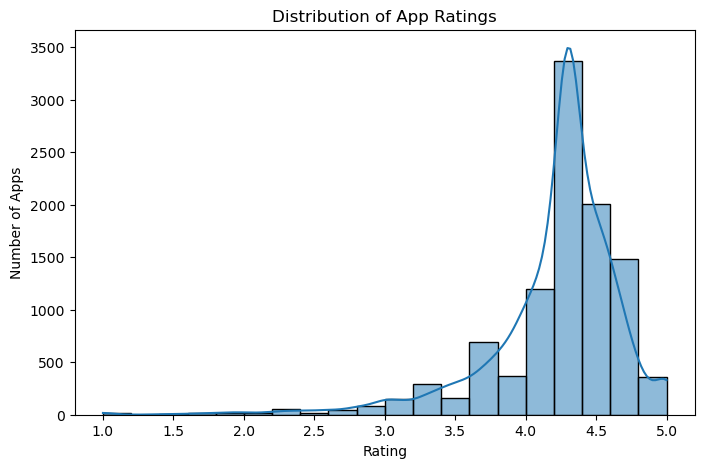

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(playstore["Rating"], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

## Visualization 2: Top 10 App Categories

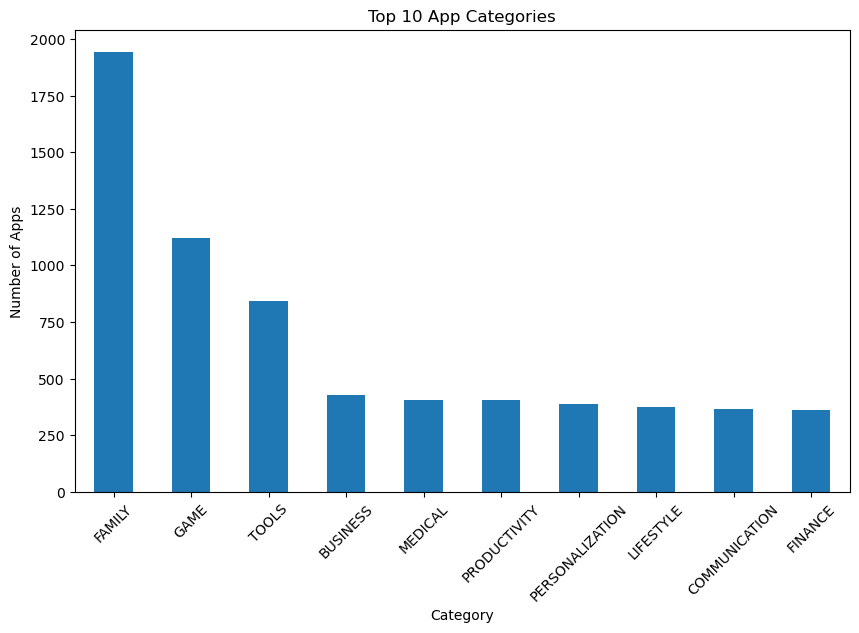

In [56]:
# Visualization 2: Top 10 App Categories
plt.figure(figsize=(10,6))

playstore["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

## Visualization 3: Free vs Paid Apps

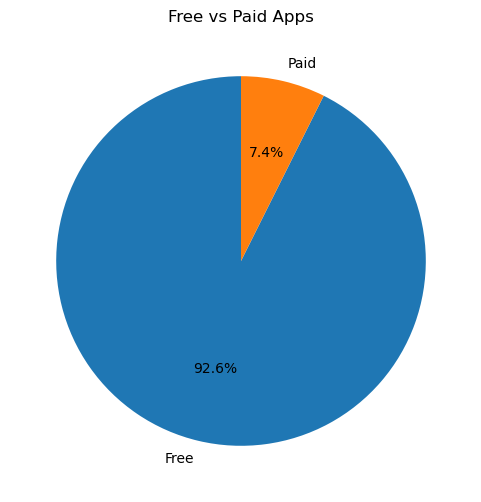

In [57]:
plt.figure(figsize=(6,6))

playstore["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Free vs Paid Apps")
plt.ylabel("")

plt.show()

## Visualization 4: Content Rating Distribution

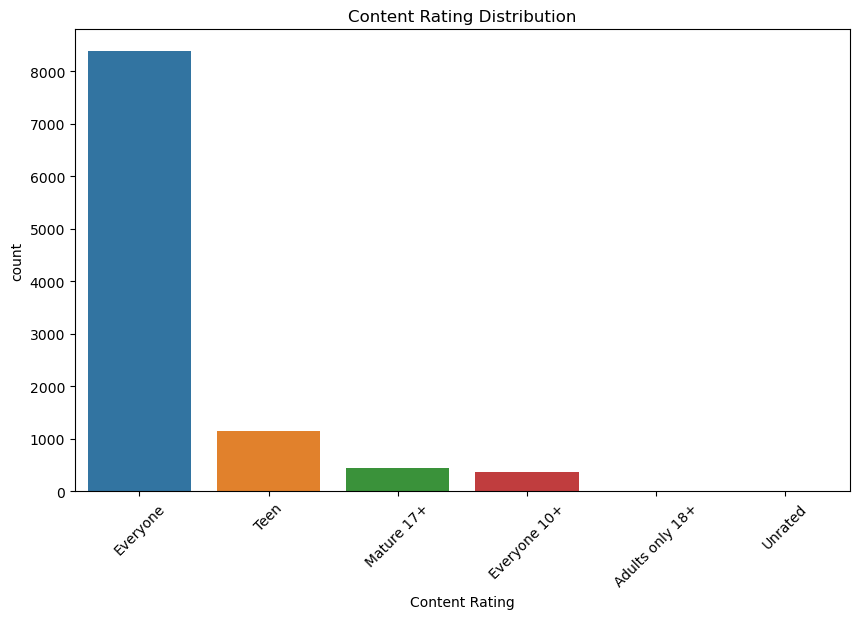

In [58]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=playstore,
    x="Content Rating",
    order=playstore["Content Rating"].value_counts().index
)

plt.title("Content Rating Distribution")
plt.xticks(rotation=45)

plt.show()

## Visualization 5: Top 10 Genres

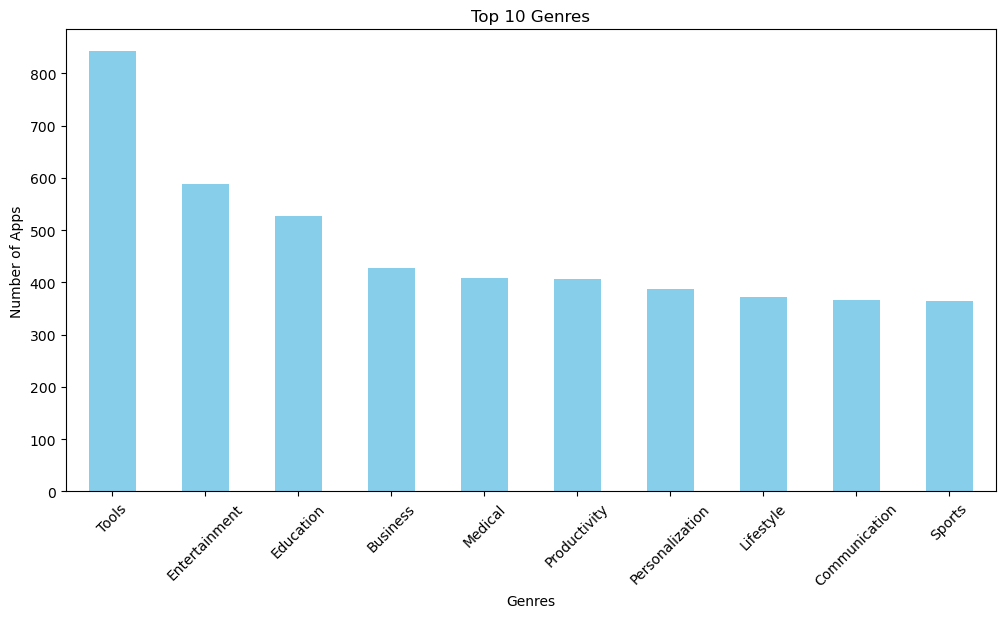

In [59]:
plt.figure(figsize=(12,6))

playstore["Genres"].value_counts().head(10).plot(kind="bar", color="skyblue")

plt.title("Top 10 Genres")
plt.xlabel("Genres")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

In [60]:
playstore.describe()

,Rating
count,10357.000000
mean,4.203737
std,0.485594
min,1.000000
25%,4.100000
50%,4.300000
75%,4.500000
max,5.000000


# Conclusion

This project analyzed the Google Play Store dataset to understand app trends and user behavior.

Key findings:

- Most apps have ratings between 4.0 and 4.5.
- Family is the category with the highest number of apps.
- Around 92.6% of apps are free, while only 7.4% are paid.
- Most apps are suitable for everyone.
- Tools, Entertainment, and Education are among the most popular genres.

Overall, the Google Play Store is dominated by free applications with high user ratings across a wide variety of categories and genres.